# U.S. PADD Crude-Oil Supply and Demand Model

This notebook documents and runs the complete model-fitting process. It reads the source archives directly from `data/eia` and `data/jodi`; it does not use the older `oil/snd` model or its outputs.

The physical balance for every PADD is:

$$Stock_{t+1} = Stock_t + Production_t - Demand_t + Imports_t - Exports_t$$

EIA supplies the five PADD histories. JODI is national-only, so it is retained as an independent U.S. benchmark after the five PADD results are aggregated.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from us_snd_model import (
    DEFAULT_EIA_FILE, DEFAULT_JODI_FILE, EIA_COMPONENT_CODES,
    FEATURE_COLUMNS, PADD_NAMES, aggregate_us, fit_padd_models,
    forecast_padd_snd_12m,
    latest_forecasts, load_eia_padd, load_jodi_us,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')

print(f'EIA source:  {DEFAULT_EIA_FILE}')
print(f'JODI source: {DEFAULT_JODI_FILE}')

EIA source:  /home/calvin/commodities/data/eia/petroleum/data/EIA_XLS_Monthly.parquet
JODI source: /home/calvin/commodities/data/jodi/JODI.parquet


## 1. Load and normalize the source data

The EIA archive is filtered to monthly crude series for PADDs 1–5. Flow observations are monthly thousand barrels (`kb`) and stocks are ending `kb`. Refinery crude input is treated as crude demand. Blank regional export cells are flagged and treated as zero for the additive balance.

In [2]:
eia = load_eia_padd(DEFAULT_EIA_FILE)
jodi = load_jodi_us(DEFAULT_JODI_FILE)

coverage = (
    eia.groupby(['padd', 'padd_name'])
       .agg(start=('month', 'min'), end=('month', 'max'), observations=('month', 'size'),
            zero_imputed_exports=('exports_imputed_zero', 'sum'))
       .reset_index()
)
coverage

,padd,padd_name,start,end,observations,zero_imputed_exports
0,1,East Coast,2007-01-01,2026-05-01,233,21
1,2,Midwest,2007-01-01,2026-05-01,233,0
2,3,Gulf Coast,2007-01-01,2026-05-01,233,63
3,4,Rocky Mountain,2007-01-01,2026-05-01,233,97
4,5,West Coast,2007-01-01,2026-05-01,233,105


In [3]:
source_keys = []
for padd, padd_name in PADD_NAMES.items():
    for column, code in EIA_COMPONENT_CODES.items():
        source_keys.append({
            'padd': padd, 'padd_name': padd_name, 'model_column': column,
            'eia_source_key': f'MCR{code}{padd}1'
        })
pd.DataFrame(source_keys).head(12)

,padd,padd_name,model_column,eia_source_key
0,1,East Coast,production_kb,MCRFPP11
1,1,East Coast,demand_kb,MCRRIP11
2,1,East Coast,imports_kb,MCRIMP11
3,1,East Coast,exports_kb,MCREXP11
4,1,East Coast,stock_kb,MCRSTP11
5,1,East Coast,reported_stock_change_kb,MCRSCP11
6,2,Midwest,production_kb,MCRFPP21
7,2,Midwest,demand_kb,MCRRIP21
8,2,Midwest,imports_kb,MCRIMP21
9,2,Midwest,exports_kb,MCREXP21


## 2. Construct the physical accounting baseline

The raw identity is calculated before fitting. `identity_error_kb` is actual next-month stock less the five-term identity. At PADD level this residual includes inter-PADD movements, transfers, and statistical adjustments that are not present in the requested equation.

In [4]:
balance_columns = [
    'month', 'padd_name', 'stock_t_kb', 'production_kb', 'demand_kb',
    'imports_kb', 'exports_kb', 'fundamental_balance_kb',
    'identity_stock_t1_kb', 'stock_t1_actual_kb', 'identity_error_kb'
]
eia[balance_columns].tail(10)

component,month,padd_name,stock_t_kb,production_kb,demand_kb,imports_kb,exports_kb,fundamental_balance_kb,identity_stock_t1_kb,stock_t1_actual_kb,identity_error_kb
1155,2025-08-01,West Coast,"46,079.00","20,285.00","69,702.00","42,538.00",0.00,"-6,879.00","39,200.00","45,411.00","6,211.00"
1156,2025-09-01,West Coast,"45,411.00","20,503.00","64,824.00","34,813.00",46.00,"-9,554.00","35,857.00","48,782.00","12,925.00"
1157,2025-10-01,West Coast,"48,782.00","21,332.00","59,215.00","30,019.00",0.00,"-7,864.00","40,918.00","45,164.00","4,246.00"
1158,2025-11-01,West Coast,"45,164.00","20,500.00","57,286.00","28,788.00",0.00,"-7,998.00","37,166.00","46,424.00","9,258.00"
1159,2025-12-01,West Coast,"46,424.00","21,459.00","62,624.00","32,179.00",85.00,"-9,071.00","37,353.00","44,359.00","7,006.00"
1160,2026-01-01,West Coast,"44,359.00","21,284.00","62,534.00","37,456.00",0.00,"-3,794.00","40,565.00","43,997.00","3,432.00"
1161,2026-02-01,West Coast,"43,997.00","18,836.00","53,046.00","26,839.00",735.00,"-8,106.00","35,891.00","44,981.00","9,090.00"
1162,2026-03-01,West Coast,"44,981.00","21,208.00","59,721.00","30,787.00",0.00,"-7,726.00","37,255.00","46,089.00","8,834.00"
1163,2026-04-01,West Coast,"46,089.00","20,888.00","56,368.00","28,793.00",760.00,"-7,447.00","38,642.00","47,371.00","8,729.00"
1164,2026-05-01,West Coast,"47,371.00","21,441.00","58,174.00","31,505.00","2,230.00","-7,458.00","39,913.00",NaN,NaN


In [5]:
identity_summary = (
    eia.dropna(subset=['stock_t1_actual_kb'])
       .groupby(['padd', 'padd_name'])
       .agg(identity_mae_kb=('identity_error_kb', lambda x: x.abs().mean()),
            identity_bias_kb=('identity_error_kb', 'mean'))
       .reset_index()
)
identity_summary

,padd,padd_name,identity_mae_kb,identity_bias_kb
0,1,East Coast,"5,239.72","4,587.29"
1,2,Midwest,"25,248.34",-179.40
2,3,Gulf Coast,"35,218.61","13,308.58"
3,4,Rocky Mountain,"13,924.53","-13,924.53"
4,5,West Coast,"5,074.25","4,312.93"


## 3. Fit one linear regression per PADD

The model uses these signed features:

- current stock
- production
- negative demand
- imports
- negative exports

`LinearRegression(positive=True)` constrains their fitted coefficients to be non-negative. Because demand and exports enter as negative-valued features, their economic effect remains negative. Validation uses 10-fold expanding-window `TimeSeriesSplit`. Each fold trains only on earlier observations and tests on the next block, preventing future leakage. Reported accuracy uses only the pooled out-of-fold predictions. A final model is then refitted on all available history for the live forecast.

In [6]:
padd_model, metrics, coefficients = fit_padd_models(eia, cv_folds=10)

metrics.round({
    'cv_mae_kb': 0, 'cv_rmse_kb': 0, 'cv_r2': 3,
    'identity_cv_mae_kb': 0
})

,padd,padd_name,cv_folds,fit_observations,cv_observations,cv_start,cv_end,cv_mae_kb,cv_rmse_kb,cv_r2,identity_cv_mae_kb
0,1,East Coast,10,232,210,2008-11-01,2026-04-01,"1,261.00","1,700.00",0.73,"5,577.00"
1,2,Midwest,10,232,210,2008-11-01,2026-04-01,"4,461.00","5,743.00",0.92,"22,806.00"
2,3,Gulf Coast,10,232,210,2008-11-01,2026-04-01,"10,968.00","14,389.00",0.98,"34,335.00"
3,4,Rocky Mountain,10,232,210,2008-11-01,2026-04-01,920.00,"1,160.00",0.93,"14,830.00"
4,5,West Coast,10,232,210,2008-11-01,2026-04-01,"1,916.00","2,435.00",0.57,"5,344.00"


In [7]:
coefficient_labels = {
    'stock_t_kb': 'Stock beta',
    'production_kb': 'Production beta',
    'demand_outflow_kb': 'Demand outflow beta',
    'imports_kb': 'Imports beta',
    'exports_outflow_kb': 'Exports outflow beta',
}
coefficients.rename(columns=coefficient_labels).round(4)

,padd,intercept_kb,Stock beta,Production beta,Demand outflow beta,Imports beta,Exports outflow beta
0,1,988.76,0.91,0.00,0.00,0.00,0.00
1,2,"20,720.83",0.93,0.14,0.18,0.00,0.00
2,3,"21,938.11",0.99,0.31,0.26,0.11,0.33
3,4,"1,711.97",0.91,0.05,0.06,0.00,0.00
4,5,"19,047.26",0.61,0.20,0.08,0.02,0.20


## 4. Inspect cross-validated results

The plots below compare actual next-month stocks with strictly out-of-fold estimates from the ten time-series folds. The early section has no estimate because `TimeSeriesSplit` reserves it to seed the first expanding training window.

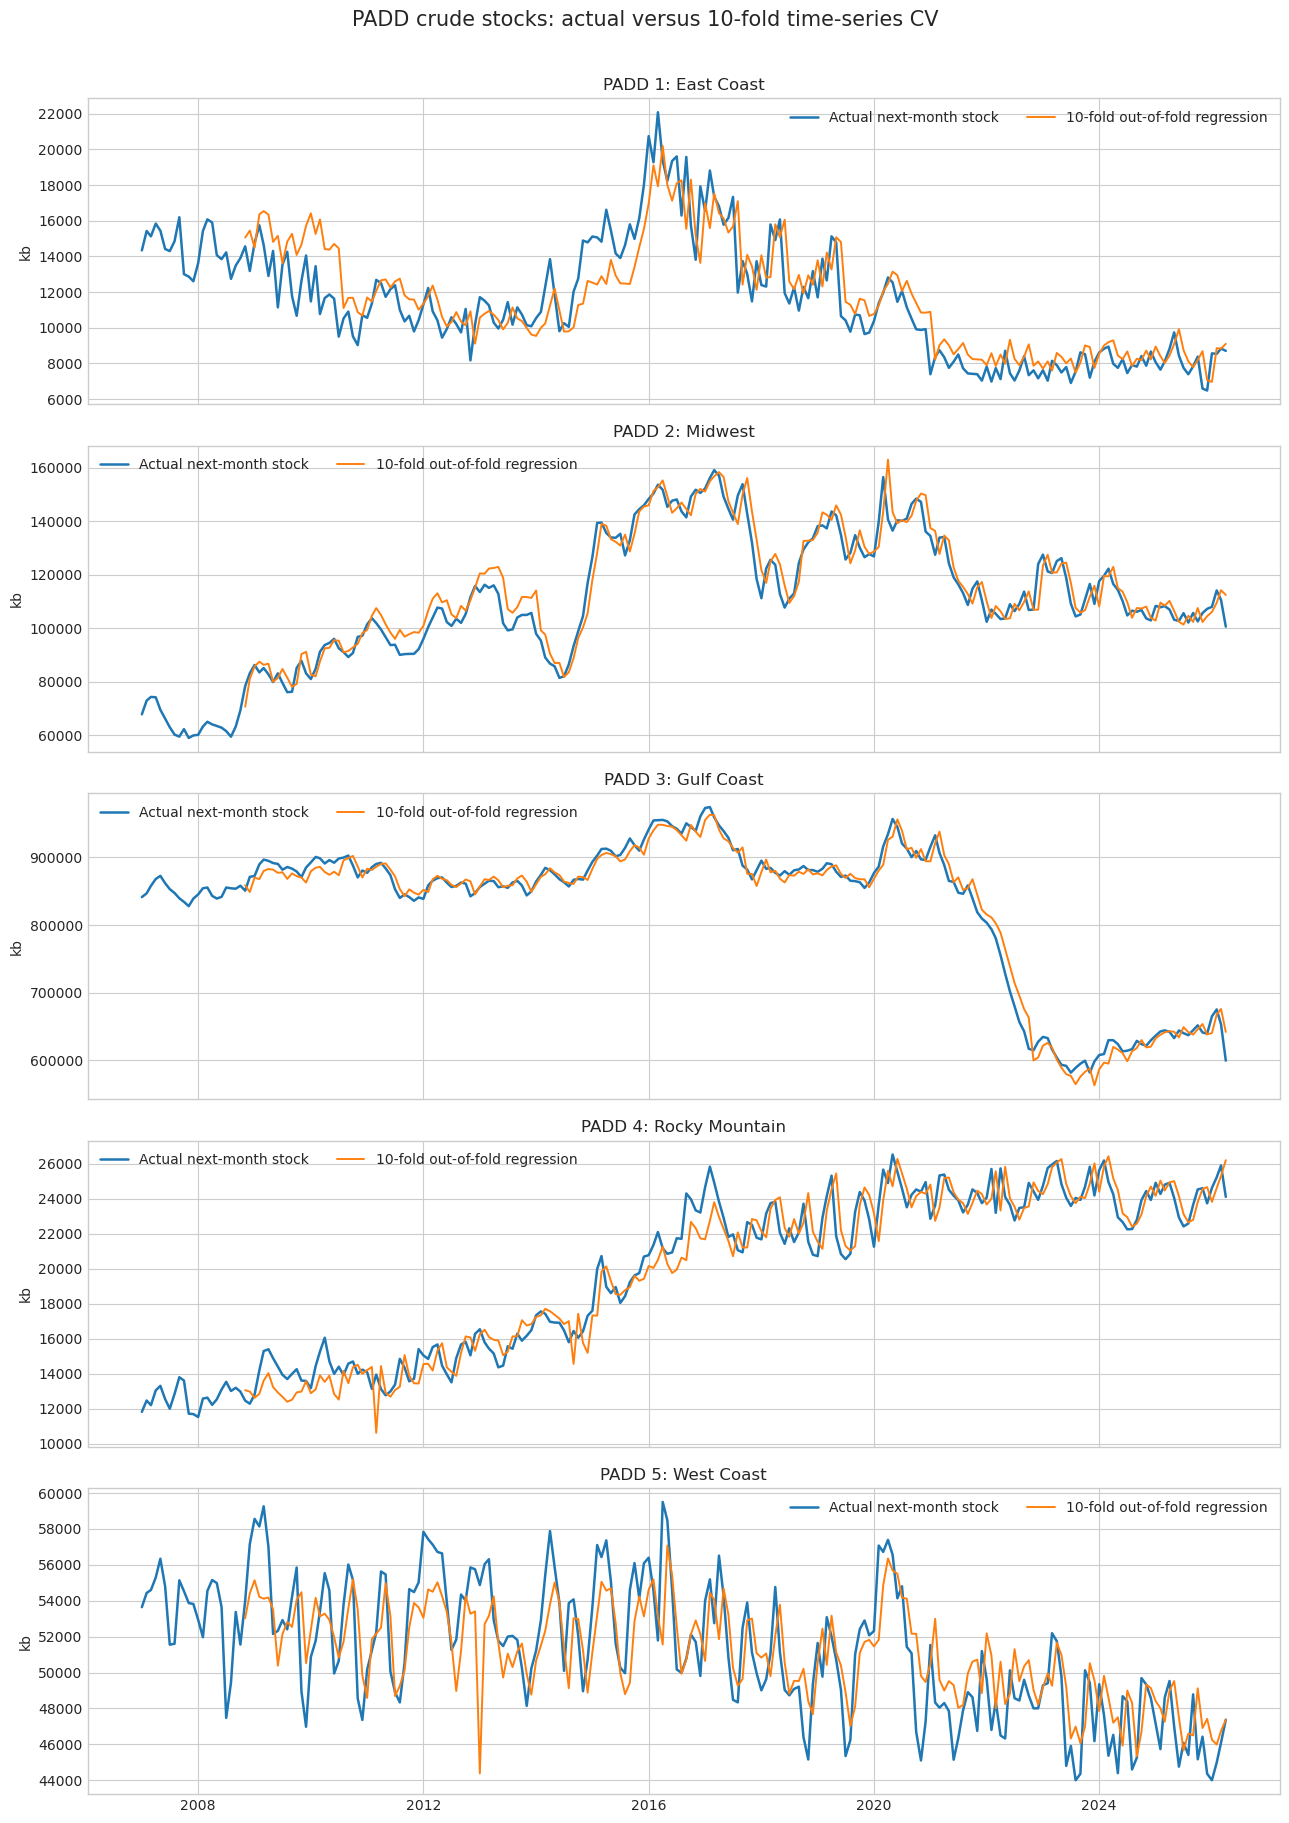

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(13, 18), sharex=True)
for ax, padd in zip(axes, sorted(PADD_NAMES)):
    frame = padd_model[padd_model['padd'] == padd]
    ax.plot(frame['month'], frame['stock_t1_actual_kb'], label='Actual next-month stock', lw=1.8)
    ax.plot(frame['month'], frame['cv_regression_stock_t1_kb'], label='10-fold out-of-fold regression', lw=1.4)
    ax.set_title(f'PADD {padd}: {PADD_NAMES[padd]}')
    ax.set_ylabel('kb')
    ax.legend(loc='best', ncol=3)
fig.suptitle('PADD crude stocks: actual versus 10-fold time-series CV', y=1.01, fontsize=15)
fig.tight_layout()
plt.show()

## 5. Aggregate PADD models into the U.S. SnD

No separate national regression is fitted. The U.S. result is the sum of the five PADD models, ensuring the national forecast is traceable to its regional components. JODI national values are then joined by month for comparison.

In [9]:
us_model = aggregate_us(padd_model, jodi)

us_display_columns = [
    'month', 'padd_count', 'us_stock_t_kb', 'us_production_kb',
    'us_demand_kb', 'us_imports_kb', 'us_exports_kb',
    'us_fundamental_balance_kb', 'us_regression_stock_t1_kb',
    'us_cv_regression_stock_t1_kb',
    'jodi_stock_kb', 'eia_minus_jodi_stock_kb'
]
us_model[us_display_columns].tail(12)

component,month,padd_count,us_stock_t_kb,us_production_kb,us_demand_kb,us_imports_kb,us_exports_kb,us_fundamental_balance_kb,us_regression_stock_t1_kb,us_cv_regression_stock_t1_kb,jodi_stock_kb,eia_minus_jodi_stock_kb
221,2025-06-01,5,"816,909.00","408,314.00","512,858.00","184,939.00","112,872.00","-32,477.00","818,163.95","817,987.06","672,223.00","144,686.00"
222,2025-07-01,5,"823,162.00","424,926.00","526,987.00","196,174.00","109,110.00","-14,997.00","828,694.33","828,049.25","678,476.00","144,686.00"
223,2025-08-01,5,"822,235.00","428,114.00","525,210.00","194,769.00","124,762.00","-27,089.00","823,824.19","823,882.58","677,551.00","144,684.00"
224,2025-09-01,5,"814,836.00","414,845.00","493,933.00","192,039.00","130,150.00","-17,199.00","817,296.04","817,639.50","670,151.00","144,685.00"
225,2025-10-01,5,"830,588.00","429,778.00","481,299.00","182,832.00","136,779.00","-5,468.00","834,225.79","834,830.88","685,906.00","144,682.00"
226,2025-11-01,5,"832,486.00","413,676.00","498,828.00","173,404.00","116,634.00","-28,382.00","836,351.64","836,295.31","687,800.00","144,686.00"
227,2025-12-01,5,"824,701.00","423,356.00","526,549.00","198,699.00","128,518.00","-33,012.00","821,128.89","822,036.34","680,023.00","144,678.00"
228,2026-01-01,5,"821,356.00","412,455.00","506,378.00","200,538.00","121,580.00","-14,965.00","823,448.07","823,693.17","693,262.00","128,094.00"
229,2026-02-01,5,"850,349.00","383,898.00","445,433.00","180,799.00","121,661.00","-2,397.00","856,618.44","856,850.94",NaN,NaN
230,2026-03-01,5,"868,249.00","425,497.00","508,285.00","202,613.00","125,332.00","-5,507.00","870,172.07","871,156.16",NaN,NaN


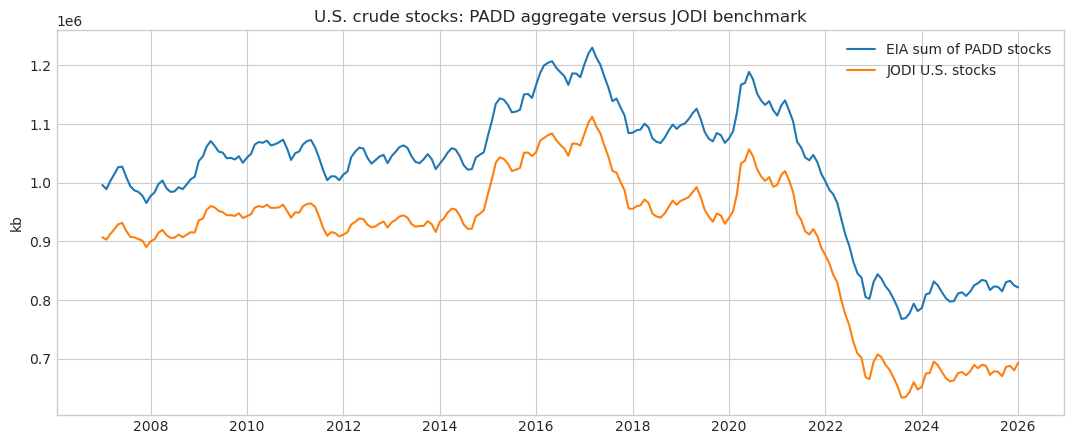

In [10]:
overlap = us_model.dropna(subset=['jodi_stock_kb'])
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(overlap['month'], overlap['us_stock_t_kb'], label='EIA sum of PADD stocks')
ax.plot(overlap['month'], overlap['jodi_stock_kb'], label='JODI U.S. stocks')
ax.set(title='U.S. crude stocks: PADD aggregate versus JODI benchmark', ylabel='kb')
ax.legend()
plt.show()

## 6. Latest PADD and U.S. forecasts

The U.S. row is the exact sum of the five regional regression forecasts. The raw identity forecast is included beside it to show how much the learned historical calibration changes the result.

In [11]:
forecasts = latest_forecasts(padd_model)
forecasts.round(0)

,padd,padd_name,month,forecast_month,stock_t_kb,fundamental_balance_kb,identity_stock_t1_kb,regression_stock_t1_kb,regression_stock_change_kb
0,3,Gulf Coast,2026-05-01,2026-06-01,"599,784.00","-114,058.00","485,726.00","580,890.00","-18,894.00"
1,2,Midwest,2026-05-01,2026-06-01,"100,616.00","17,039.00","117,655.00","100,353.00",-263.00
2,1,East Coast,2026-05-01,2026-06-01,"8,707.00","-8,437.00",270.00,"8,941.00",234.00
3,4,Rocky Mountain,2026-05-01,2026-06-01,"24,106.00","24,642.00","48,748.00","24,281.00",175.00
4,5,West Coast,2026-05-01,2026-06-01,"47,371.00","-7,458.00","39,913.00","47,589.00",218.00
5,0,United States (sum of PADDs),2026-05-01,2026-06-01,"780,584.00","-88,272.00","692,312.00","762,055.00","-18,529.00"


In [12]:
us_forecast = forecasts.loc[forecasts['padd'] == 0].iloc[0]
print(f"Forecast month: {us_forecast['forecast_month']:%B %Y}")
print(f"U.S. regression stock forecast: {us_forecast['regression_stock_t1_kb']:,.0f} kb")
print(f"U.S. regression stock change:   {us_forecast['regression_stock_change_kb']:,.0f} kb")
print(f"U.S. raw-identity stock:         {us_forecast['identity_stock_t1_kb']:,.0f} kb")

Forecast month: June 2026
U.S. regression stock forecast: 762,055 kb
U.S. regression stock change:   -18,529 kb
U.S. raw-identity stock:         692,312 kb


## 7. Forecast supply and demand for the next 12 months

Each PADD flow is forecast independently with a linear regression containing a time trend and monthly fixed effects, fitted on the latest 120 months. The four forecast components are then combined as:

- **Supply** = production + imports
- **Refinery demand** = refiner crude input
- **Total demand/disposition** = refinery demand + exports
- **Balance** = supply - total demand/disposition

The forecast flows feed each PADD's full-history stock regression recursively. Finally, all five PADD paths are summed to produce the U.S. forecast.

In [13]:
padd_forecast_12m, us_forecast_12m = forecast_padd_snd_12m(
    padd_model, coefficients, horizon=12, lookback_months=120
)

us_12m_columns = [
    'month', 'forecast_production_kb', 'forecast_imports_kb',
    'forecast_supply_kb', 'forecast_refinery_demand_kb',
    'forecast_exports_kb', 'forecast_total_demand_kb',
    'forecast_balance_kb', 'regression_stock_kb'
]
us_forecast_12m[us_12m_columns].round(0)

,month,forecast_production_kb,forecast_imports_kb,forecast_supply_kb,forecast_refinery_demand_kb,forecast_exports_kb,forecast_total_demand_kb,forecast_balance_kb,regression_stock_kb
0,2026-06-01,"419,497.00","180,162.00","599,659.00","492,790.00","145,615.00","638,405.00","-38,747.00","776,793.00"
1,2026-07-01,"433,812.00","185,336.00","619,149.00","508,925.00","147,505.00","656,431.00","-37,282.00","773,488.00"
2,2026-08-01,"437,220.00","181,986.00","619,206.00","509,118.00","149,353.00","658,471.00","-39,265.00","769,802.00"
3,2026-09-01,"427,160.00","171,287.00","598,447.00","473,876.00","148,300.00","622,176.00","-23,729.00","770,762.00"
4,2026-10-01,"442,991.00","170,439.00","613,430.00","476,848.00","154,096.00","630,944.00","-17,514.00","771,521.00"
5,2026-11-01,"437,192.00","169,266.00","606,458.00","483,024.00","150,905.00","633,929.00","-27,471.00","770,526.00"
6,2026-12-01,"447,041.00","177,657.00","624,697.00","503,666.00","157,379.00","661,045.00","-36,348.00","765,935.00"
7,2027-01-01,"442,520.00","182,723.00","625,243.00","487,442.00","153,273.00","640,715.00","-15,471.00","765,763.00"
8,2027-02-01,"410,195.00","155,829.00","566,024.00","425,922.00","152,848.00","578,771.00","-12,747.00","768,684.00"
9,2027-03-01,"451,910.00","173,987.00","625,898.00","485,655.00","160,386.00","646,041.00","-20,144.00","767,854.00"


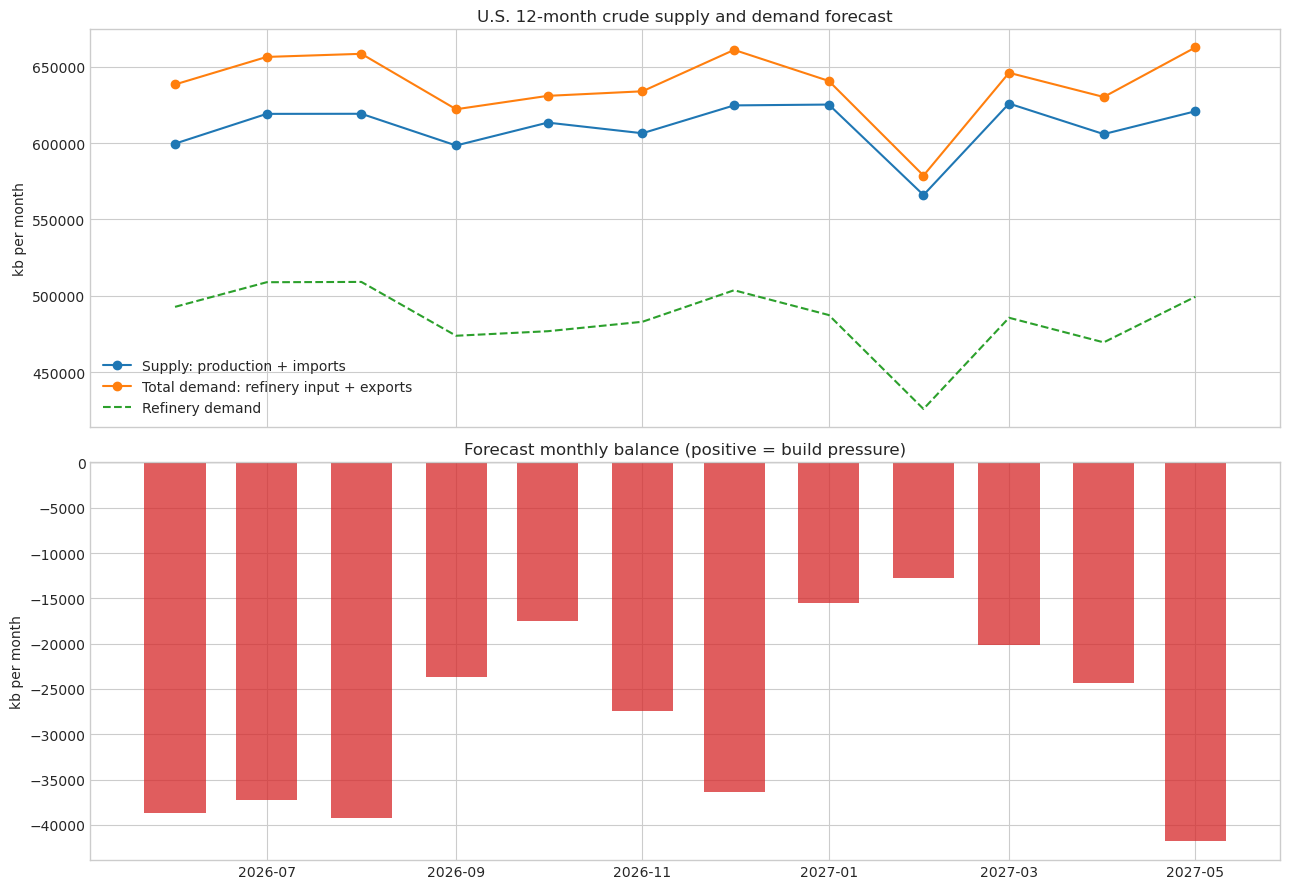

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
axes[0].plot(us_forecast_12m['month'], us_forecast_12m['forecast_supply_kb'], marker='o', label='Supply: production + imports')
axes[0].plot(us_forecast_12m['month'], us_forecast_12m['forecast_total_demand_kb'], marker='o', label='Total demand: refinery input + exports')
axes[0].plot(us_forecast_12m['month'], us_forecast_12m['forecast_refinery_demand_kb'], linestyle='--', label='Refinery demand')
axes[0].set(title='U.S. 12-month crude supply and demand forecast', ylabel='kb per month')
axes[0].legend()
colors = np.where(us_forecast_12m['forecast_balance_kb'] >= 0, 'tab:green', 'tab:red')
axes[1].bar(us_forecast_12m['month'], us_forecast_12m['forecast_balance_kb'], width=20, color=colors, alpha=0.75)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set(title='Forecast monthly balance (positive = build pressure)', ylabel='kb per month')
fig.tight_layout()
plt.show()

In [15]:
padd_12m_summary = (
    padd_forecast_12m.groupby(['padd', 'padd_name'])
    .agg(
        average_monthly_supply_kb=('forecast_supply_kb', 'mean'),
        average_monthly_total_demand_kb=('forecast_total_demand_kb', 'mean'),
        cumulative_balance_kb=('forecast_balance_kb', 'sum'),
        ending_regression_stock_kb=('regression_stock_kb', 'last'),
    )
    .reset_index()
)
padd_12m_summary.round(0)

,padd,padd_name,average_monthly_supply_kb,average_monthly_total_demand_kb,cumulative_balance_kb,ending_regression_stock_kb
0,1,East Coast,"17,128.00","18,977.00","-22,190.00","10,501.00"
1,2,Midwest,"145,824.00","121,457.00","292,399.00","104,698.00"
2,3,Gulf Coast,"348,445.00","419,477.00","-852,382.00","570,747.00"
3,4,Rocky Mountain,"44,174.00","17,617.00","318,681.00","25,884.00"
4,5,West Coast,"54,843.00","60,787.00","-71,336.00","47,782.00"


## Interpretation and limitations

The regressions substantially reduce pooled 10-fold out-of-fold error relative to the literal five-term PADD identity, especially where unobserved regional transfers are large. The estimates should be interpreted as statistical stock forecasts conditioned on reported monthly flows—not as a replacement for complete physical balance accounting.

Important limitations:

- PADD-level interregional movements and transfers are omitted from the requested five-term equation.
- Blank EIA regional export cells are treated as zero and explicitly flagged.
- JODI definitions and coverage can differ from the EIA PADD sum, so JODI is a benchmark rather than a training target.
- The 12-month flow forecast extrapolates linear trend and monthly seasonality; it does not include future shocks or scenario assumptions.

## Detailed model and fit notes

### Constrained PADD linear regressions

Each PADD model is a multiple linear regression of next-month stock on current stock and the four signed balance flows. Non-negative coefficients are applied to current stock, production, negative refinery demand, imports, and negative exports. This preserves the intended direction of the physical equation while allowing the data to shrink unreliable regional flow effects. The ten expanding-window folds produce 210 strictly out-of-fold predictions per PADD; the final coefficients shown above are then refitted on all 232 usable observations only for forecasting.

The stock coefficient is the dominant term in every region, ranging from 0.609 in PADD 5 to 0.987 in PADD 3. This confirms strong month-to-month inventory persistence. PADD 1's flow coefficients shrink to zero, meaning its reported production, refinery input, and trade add no stable incremental signal once current stocks are known. PADD 3 retains all four flow effects and is the region where the requested physical drivers contribute most consistently. Zero coefficients should be read as evidence of weak incremental predictive value under the sign constraint—not proof that the physical flow is literally irrelevant.

### PADD-by-PADD fit

- **PADD 1 — East Coast:** CV MAE is 1,261 kb, RMSE is 1,700 kb, and R² is 0.726. The regression reduces error by about 77% relative to the literal identity's 5,577 kb MAE, but the moderate R² and zero flow coefficients show that the model is mostly a mean-reverting stock-persistence model.
- **PADD 2 — Midwest:** CV MAE is 4,461 kb, RMSE is 5,743 kb, and R² is 0.923. This is a strong level fit and an 80% MAE reduction versus the raw identity. Production and refinery-demand terms remain active; exports shrink to zero.
- **PADD 3 — Gulf Coast:** CV MAE is 10,968 kb and RMSE is 14,389 kb. These are the largest absolute errors because PADD 3 has by far the largest stock base and flow volatility, while R² remains very high at 0.984. The regression improves MAE by about 68% versus the identity and uses every flow component.
- **PADD 4 — Rocky Mountain:** CV MAE is 920 kb, RMSE is 1,160 kb, and R² is 0.928. The roughly 94% MAE reduction versus the identity is the largest regional improvement, consistent with omitted inter-PADD transfers making the five-term raw balance especially incomplete here.
- **PADD 5 — West Coast:** CV MAE is 1,916 kb, RMSE is 2,435 kb, and R² is only 0.574. The model still cuts identity MAE by about 64%, but this is the weakest proportional level fit and suggests regime changes or omitted regional movements that a fixed linear relationship cannot fully capture.

### U.S. aggregation and JODI comparison

The national model is not independently fitted: every U.S. value is the sum of the five PADD estimates. This preserves regional traceability. JODI is used only as a national benchmark because it has no PADD dimension. Persistent EIA–JODI level differences reflect coverage and definition differences, so convergence between the two sources is not used as a training objective.

### Twelve-month forecast interpretation

The forward flow regressions imply average monthly U.S. supply of about 610,414 kb and average total demand/disposition of 638,316 kb, a mean deficit of roughly 27,902 kb per month. The literal cumulative balance therefore draws 334,828 kb over the horizon and ends at 445,756 kb, whereas the calibrated recursive stock regressions end near 759,611 kb. That large gap is an important warning: the five-term PADD identity omits transfers and statistical adjustments, and extrapolating its raw imbalance mechanically produces a much more severe stock draw than the historically calibrated regressions. The regression path is statistically more consistent with history, but neither path incorporates future outages, policy changes, price responses, or geopolitical scenarios.